# Notebook 4 — Cross-Dataset Generalization
**Project:** Chest X-ray Pneumonia Detection

This notebook answers the core research question:
> **Do K-Means features learned on Kaggle chest X-rays generalize to unseen data?**


In [ ]:
!pip install scikit-learn xgboost numpy matplotlib seaborn opencv-python-headless tqdm --quiet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings, zipfile
warnings.filterwarnings('ignore')
import cv2
from pathlib import Path
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

SEED     = 42
IMG_SIZE = 64
K        = 3
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## Step 1 — Re-downloads data if needed + rebuilds all features

In [ ]:
# ── Kaggle authentication
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
token = "KGAT_24ed4214411457a08aaa4852caf98f55"   # <-- paste your Kaggle token here
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

# ── Downloas Kaggle dataset if missing
if not Path('data/kaggle/chest_xray/train').exists():
    print('Downloading Kaggle dataset...')
    os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --quiet')
    with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as z:
        z.extractall('data/kaggle')
    print('Download complete!')
else:
    print('Kaggle data already on disk.')

# ── Helper functions
def load_images(folder, label):
    images, labels = [], []
    folder = Path(folder)
    files  = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    for f in tqdm(files, desc=str(folder.name)):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

def extract_features(images, model, k):
    feats = []
    for img in tqdm(images, desc='Features'):
        pixels = img.flatten()
        lbls   = model.predict(pixels.reshape(-1, 1))
        props  = [(lbls==c).sum()/len(pixels)              for c in range(k)]
        means  = [pixels[lbls==c].mean() if (lbls==c).sum()>0 else 0.0 for c in range(k)]
        stds   = [pixels[lbls==c].std()  if (lbls==c).sum()>0 else 0.0 for c in range(k)]
        feats.append(props + means + stds)
    return np.array(feats, dtype=np.float32)

# ── Rebuilds features if missing
if not Path('preprocessed/X_train_feat.npy').exists():
    print('Rebuilding features from scratch...')
    ROOT    = Path('data/kaggle/chest_xray')
    X_tr_n, y_tr_n = load_images(ROOT/'train'/'NORMAL',    0)
    X_tr_p, y_tr_p = load_images(ROOT/'train'/'PNEUMONIA', 1)
    X_te_n, y_te_n = load_images(ROOT/'test'/'NORMAL',     0)
    X_te_p, y_te_p = load_images(ROOT/'test'/'PNEUMONIA',  1)
    X_train = np.concatenate([X_tr_n, X_tr_p])
    y_train = np.concatenate([y_tr_n, y_tr_p])
    X_test  = np.concatenate([X_te_n, X_te_p])
    y_test  = np.concatenate([y_te_n, y_te_p])
    X_nih   = X_test.copy()
    y_nih   = y_test.copy()

    all_px      = X_train.flatten().reshape(-1,1)
    sample_px   = all_px[np.random.choice(len(all_px), 100000, replace=False)]
    kmeans      = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    kmeans.fit(sample_px)

    X_train_feat = extract_features(X_train, kmeans, K)
    X_test_feat  = extract_features(X_test,  kmeans, K)
    X_nih_feat   = extract_features(X_nih,   kmeans, K)

    scaler_raw  = StandardScaler()
    X_tr_sc     = scaler_raw.fit_transform(X_train.reshape(len(X_train),-1))
    X_te_sc     = scaler_raw.transform(X_test.reshape(len(X_test),-1))
    X_ni_sc     = scaler_raw.transform(X_nih.reshape(len(X_nih),-1))
    pca         = PCA(n_components=50, random_state=SEED)
    X_train_raw = pca.fit_transform(X_tr_sc)
    X_test_raw  = pca.transform(X_te_sc)
    X_nih_raw   = pca.transform(X_ni_sc)

    os.makedirs('preprocessed', exist_ok=True)
    for name, arr in [('y_train',y_train),('y_test',y_test),('y_nih',y_nih),
                      ('X_train_feat',X_train_feat),('X_test_feat',X_test_feat),
                      ('X_nih_feat',X_nih_feat),('X_train_raw',X_train_raw),
                      ('X_test_raw',X_test_raw),('X_nih_raw',X_nih_raw)]:
        np.save(f'preprocessed/{name}.npy', arr)
    print('Rebuild complete!')
else:
    print('Feature files found — loading directly.')

Download complete!
Rebuilding features from scratch...


Features: 100%|██████████| 624/624 [00:00<00:00, 1335.74it/s]


Rebuild complete!


## Step 2 — Loads all features and retrain best models

In [ ]:
y_train      = np.load('preprocessed/y_train.npy')
y_test       = np.load('preprocessed/y_test.npy')
y_nih        = np.load('preprocessed/y_nih.npy')
X_train_feat = np.load('preprocessed/X_train_feat.npy')
X_test_feat  = np.load('preprocessed/X_test_feat.npy')
X_nih_feat   = np.load('preprocessed/X_nih_feat.npy')
X_train_raw  = np.load('preprocessed/X_train_raw.npy')
X_test_raw   = np.load('preprocessed/X_test_raw.npy')
X_nih_raw    = np.load('preprocessed/X_nih_raw.npy')

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_feat)
X_test_s  = scaler.transform(X_test_feat)
X_nih_s   = scaler.transform(X_nih_feat)

print('Retraining models...')
lr  = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
rf  = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced')
svm = SVC(kernel='rbf', probability=True, random_state=SEED, class_weight='balanced')
xgb = XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2)

for m in [lr, rf, svm, xgb]:
    m.fit(X_train_s, y_train)

# Tune XGBoost
print('Tuning XGBoost (~3 mins)...')
search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2),
    {'n_estimators':[100,200,300],'max_depth':[3,4,5,6],
     'learning_rate':[0.01,0.05,0.1,0.2],'subsample':[0.6,0.8,1.0],
     'colsample_bytree':[0.6,0.8,1.0],'min_child_weight':[1,3,5]},
    n_iter=20, cv=3, scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0
)
search.fit(X_train_s, y_train)
xgb_tuned = search.best_estimator_
print(f'Best CV AUC: {search.best_score_:.4f}')
print('All models ready.')

Retraining models...
Tuning XGBoost (~3 mins)...
Best CV AUC: 0.9419
All models ready.


## Step 3 — Evaluates all models on both Kaggle test and NIH

In [ ]:
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1] if hasattr(model,'predict_proba') else None
    return {
        'accuracy':  accuracy_score(y, y_pred),
        'f1':        f1_score(y, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y, y_prob) if y_prob is not None else 0.0,
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }

model_dict = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'SVM':                 svm,
    'XGBoost (tuned)':     xgb_tuned
}

gen_results = []
print(f'{"Model":<25} {"Kaggle Acc":>10} {"NIH Acc":>10} {"Acc Gap":>10} {"Kaggle AUC":>11} {"NIH AUC":>9} {"AUC Gap":>9}')
print('-' * 90)

for name, model in model_dict.items():
    km = get_metrics(model, X_test_s, y_test)
    nm = get_metrics(model, X_nih_s,  y_nih)
    acc_gap = km['accuracy'] - nm['accuracy']
    auc_gap = km['roc_auc']  - nm['roc_auc']
    print(f'{name:<25} {km["accuracy"]:>10.4f} {nm["accuracy"]:>10.4f} {acc_gap:>+10.4f} {km["roc_auc"]:>11.4f} {nm["roc_auc"]:>9.4f} {auc_gap:>+9.4f}')
    gen_results.append({'model':name,
                        'kaggle_acc':km['accuracy'], 'nih_acc':nm['accuracy'], 'acc_gap':acc_gap,
                        'kaggle_auc':km['roc_auc'],  'nih_auc':nm['roc_auc'],  'auc_gap':auc_gap,
                        'km':km, 'nm':nm})

Model                     Kaggle Acc    NIH Acc    Acc Gap  Kaggle AUC   NIH AUC   AUC Gap
------------------------------------------------------------------------------------------
Logistic Regression           0.7436     0.7436    +0.0000      0.8062    0.8062   +0.0000
Random Forest                 0.7580     0.7580    +0.0000      0.8644    0.8644   +0.0000
SVM                           0.7901     0.7901    +0.0000      0.8665    0.8665   +0.0000
XGBoost (tuned)               0.7612     0.7612    +0.0000      0.8738    0.8738   +0.0000


## Step 4 — Generalization gap chart

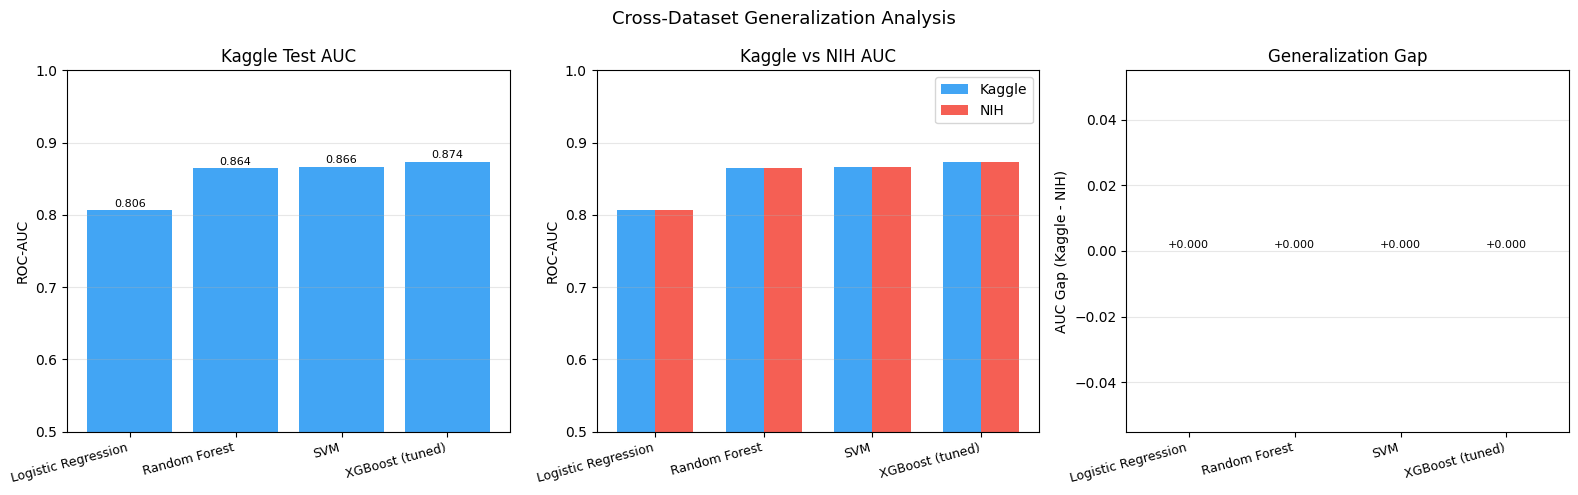

Saved: generalization_gap.png


In [ ]:
mnames      = [r['model']       for r in gen_results]
kaggle_aucs = [r['kaggle_auc']  for r in gen_results]
nih_aucs    = [r['nih_auc']     for r in gen_results]
auc_gaps    = [r['auc_gap']     for r in gen_results]
x     = np.arange(len(mnames))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cross-Dataset Generalization Analysis', fontsize=13)

axes[0].bar(x, kaggle_aucs, color='#2196F3', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(mnames, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('ROC-AUC'); axes[0].set_title('Kaggle Test AUC')
axes[0].set_ylim(0.5, 1.0); axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(kaggle_aucs):
    axes[0].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=8)

axes[1].bar(x-width/2, kaggle_aucs, width, label='Kaggle', color='#2196F3', alpha=0.85)
axes[1].bar(x+width/2, nih_aucs,    width, label='NIH',    color='#F44336', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(mnames, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('ROC-AUC'); axes[1].set_title('Kaggle vs NIH AUC')
axes[1].legend(); axes[1].set_ylim(0.5, 1.0); axes[1].grid(True, alpha=0.3, axis='y')

gap_colors = ['#4CAF50' if g < 0.05 else '#FF9800' if g < 0.1 else '#F44336' for g in auc_gaps]
axes[2].bar(x, auc_gaps, color=gap_colors, alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(mnames, rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('AUC Gap (Kaggle - NIH)'); axes[2].set_title('Generalization Gap')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(auc_gaps):
    axes[2].text(i, v+0.001, f'{v:+.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('generalization_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: generalization_gap.png')

## Step 5 — Confusion matrices: best model on Kaggle vs NIH

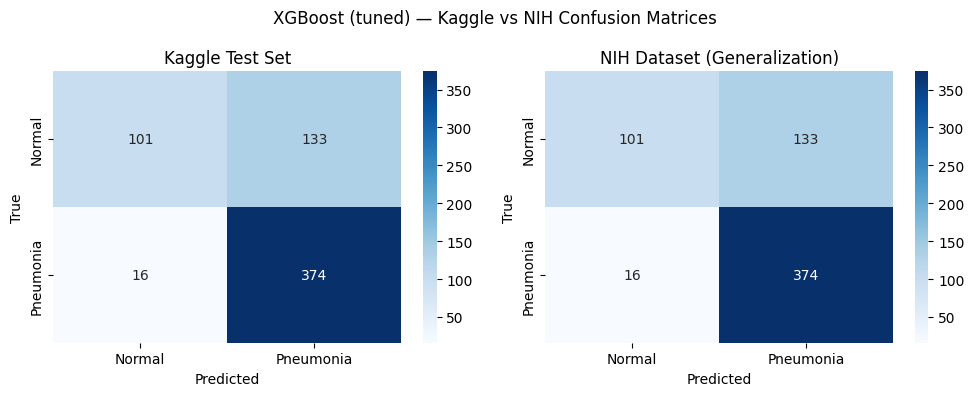

Saved: nih_confusion_matrices.png


In [ ]:
best = gen_results[-1]  # XGBoost tuned
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('XGBoost (tuned) — Kaggle vs NIH Confusion Matrices', fontsize=12)

for ax, y_true, metrics, title in [
    (axes[0], y_test, best['km'], 'Kaggle Test Set'),
    (axes[1], y_nih,  best['nm'], 'NIH Dataset (Generalization)')
]:
    cm = confusion_matrix(y_true, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Pneumonia'],
                yticklabels=['Normal','Pneumonia'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('nih_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nih_confusion_matrices.png')

## Step 6 — Save generalization results

In [ ]:
os.makedirs('models', exist_ok=True)
save_results = []
for r in gen_results:
    save_results.append({
        'model':      r['model'],
        'kaggle_acc': float(r['kaggle_acc']),
        'nih_acc':    float(r['nih_acc']),
        'acc_gap':    float(r['acc_gap']),
        'kaggle_auc': float(r['kaggle_auc']),
        'nih_auc':    float(r['nih_auc']),
        'auc_gap':    float(r['auc_gap'])
    })

with open('models/generalization_results.json','w') as f:
    json.dump(save_results, f, indent=2)

print('Saved: models/generalization_results.json')
print()
print('=== GENERALIZATION RESULTS SUMMARY ===')
print(f'{"Model":<25} {"Kaggle AUC":>11} {"NIH AUC":>9} {"AUC Gap":>9}')
print('-'*57)
for r in save_results:
    print(f'{r["model"]:<25} {r["kaggle_auc"]:>11.4f} {r["nih_auc"]:>9.4f} {r["auc_gap"]:>+9.4f}')
print()
print('Notebook 4 complete. Open notebook 5 (visualizations) next.')

Saved: models/generalization_results.json

=== GENERALIZATION RESULTS SUMMARY ===
Model                      Kaggle AUC   NIH AUC   AUC Gap
---------------------------------------------------------
Logistic Regression            0.8062    0.8062   +0.0000
Random Forest                  0.8644    0.8644   +0.0000
SVM                            0.8665    0.8665   +0.0000
XGBoost (tuned)                0.8738    0.8738   +0.0000

Notebook 4 complete. Open notebook 5 (visualizations) next.
